Introduction to Reinforcement Learning Environments: CartPole
===========================================================

Before we dive into complex Machine Learning algorithms and Deep Neural Networks, it is crucial to understand the environment we are trying to solve.

In this notebook, we will:
1. Explore the classical **CartPole-v1** environment from the `Gymnasium` library.
2. Understand the **Observation Space** (what the agent sees) and the **Action Space** (what the agent can do).
3. Solve the environment using a **Simple Heuristic Policy** (a hand-crafted mathematical rule) without any AI or training.

This gives us a baseline and proves that some problems can be solved with simple control logic, while motivating the need for AI in much harder scenarios.

## 1. Setup and Installation
Let's install the `gymnasium` library, which contains the physics simulation for CartPole.

In [ ]:
!pip install -q gymnasium[classic_control] matplotlib

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import time

## 2. Understanding the Environment
The goal in CartPole is to keep a pole balanced upright on a moving cart.
- You get **+1 reward** for every step the pole remains upright.
- The game ends (terminates) if the pole falls over too far, or if the cart moves completely off the screen.
- "Winning" the game usually means surviving for 500 consecutive steps.

In [ ]:
env = gym.make("CartPole-v1")
state, info = env.reset()

print("=== ACTION SPACE ===")
print(f"Actions available: {env.action_space}")
print("0: Push cart to the LEFT")
print("1: Push cart to the RIGHT\n")

print("=== OBSERVATION SPACE ===")
print(f"Observation array shape: {env.observation_space}")
print("When we reset the environment, we get an array of 4 numbers:")
print(f"State: {state}\n")
print("What do these numbers mean?")
print(f"Index 0: Cart Position         (Current: {state[0]:.4f})")
print(f"Index 1: Cart Velocity         (Current: {state[1]:.4f})")
print(f"Index 2: Pole Angle            (Current: {state[2]:.4f})")
print(f"Index 3: Pole Angular Velocity (Current: {state[3]:.4f})")

=== ACTION SPACE ===
Actions available: Discrete(2)
0: Push cart to the LEFT
1: Push cart to the RIGHT

=== OBSERVATION SPACE ===
Observation array shape: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
When we reset the environment, we get an array of 4 numbers:
State: [ 0.04144316  0.01630655  0.00330859 -0.01048647]

What do these numbers mean?
Index 0: Cart Position         (Current: 0.0414)
Index 1: Cart Velocity         (Current: 0.0163)
Index 2: Pole Angle            (Current: 0.0033)
Index 3: Pole Angular Velocity (Current: -0.0105)


## 3. STUDENT TASK: Create a Hand-Crafted Heuristic Policy
Instead of using a Neural Network, let's use human logic and basic physics.

**The Logic:**
If the pole is falling to the right (Angle > 0), we should push the cart to the right (Action 1) to slide underneath it and keep it balanced.
If the pole is falling to the left (Angle < 0), we should push the cart to the left (Action 0).

**YOUR MISSION:**
Write the **simplest possible formula** for `balance_score` using the available variables.
Your goal is to achieve a perfect average score of **500.0 steps** over **1000 episodes**.

In [ ]:
def heuristic_policy(observation):
    """
    A simple rule-based policy to solve CartPole.
    Takes the 4-number observation array and returns action 0 or 1.
    """
    cart_position = observation[0]
    cart_velocity = observation[1]
    pole_angle = observation[2]
    pole_angular_velocity = observation[3]

    # ==========================================
    # TODO: STUDENT TASK
    # Replace the 0.0 below with your own formula.
    # Find the simplest combination of variables to keep the pole balanced.
    # ==========================================

    alpha = 0.5

    balance_score = pole_angle + alpha * pole_angular_velocity

    # ==========================================

    # If the score is positive (falling right), push right.
    # If the score is negative (falling left), push left.
    if balance_score > 0:
        return 1  # Move Right
    else:
        return 0  # Move Left

## 4. Testing your Heuristic
Let's play **1000 episodes** using your simple `heuristic_policy` and see how long it survives. Remember, no AI training is happening here! The rules are fixed by your formula.

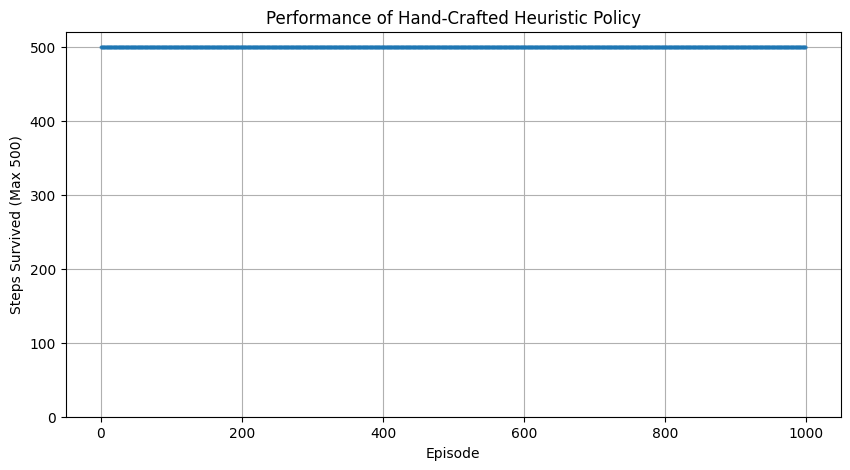


Average score over 1000 episodes: 500.0 steps!

🏆 AMAZING! Your simple formula perfectly solved the game! 🏆
You achieved the maximum possible score across all 1000 games.


In [ ]:
num_episodes = 1000
episode_durations = []

for i_episode in range(num_episodes):
    state, info = env.reset()
    survived_steps = 0

    while True:
        # Ask our human-made function what to do
        action = heuristic_policy(state)

        # Take the step in the environment
        state, reward, terminated, truncated, info = env.step(action)

        survived_steps += 1

        if terminated or truncated:
            episode_durations.append(survived_steps)
            break

env.close()

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(episode_durations, marker='o', linestyle='-', markersize=2, alpha=0.5)
plt.title('Performance of Hand-Crafted Heuristic Policy')
plt.xlabel('Episode')
plt.ylabel('Steps Survived (Max 500)')
plt.ylim(0, 520)
plt.grid(True)
plt.show()

average_score = np.mean(episode_durations)
print(f"\nAverage score over {num_episodes} episodes: {average_score:.1f} steps!")

if average_score == 500.0:
    print("\n🏆 AMAZING! Your simple formula perfectly solved the game! 🏆")
    print("You achieved the maximum possible score across all 1000 games.")
else:
    print("\n❌ Keep trying! Your goal is to achieve a perfect 500.0 average.")
    print("Hint: Look closely at the `pole_angle` and `pole_angular_velocity`.")

## 5. Rendering the Result
Let's record a video of your heuristic agent in action. Watch how smoothly it balances the pole using just your logic.

In [ ]:
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay
from gymnasium.wrappers import RecordVideo

def show_video():
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        html_data = f'<video alt="test" autoplay loop controls style="height: 400px;"><source src="data:video/mp4;base64,{encoded.decode("ascii")}" type="video/mp4" /></video>'
        ipythondisplay.display(HTML(data=html_data))
    else:
        print("Could not find video")

# Initialize the environment with RecordVideo wrapper
env_eval = RecordVideo(gym.make("CartPole-v1", render_mode='rgb_array'), "./video", disable_logger=True)
state, info = env_eval.reset()

while True:
    # Using our non-AI heuristic policy
    action = heuristic_policy(state)

    state, reward, terminated, truncated, info = env_eval.step(action)
    done = terminated or truncated

    # terminated: Episode ended because the task was completed or failed (agent reached goal, died, etc.)
    # truncated: Episode ended due to external constraints (time limit, step limit, etc.)

    if done:
        break

env_eval.close()
show_video()

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


## Conclusion & Why use Machine Learning?

If you managed to get 500 steps, you achieved a perfect score using a simple math formula!

**So why do we need Reinforcement Learning and Neural Networks?**
Because in this example, we *knew* the rules of physics. We knew that `state[2]` was the pole angle, and we knew how to write a logical rule to fix it.

In the real world (e.g., self-driving cars, playing complex video games from screen pixels, or controlling multi-jointed robots), the math is too complicated for a human to write down in an `if/else` statement. In the next tutorials, we will pretend we don't know the physics, and we will force an AI agent to discover this balancing strategy entirely by trial and error using **Deep Q-Learning (DQN)**!